In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-darkgrid')

import yfinance as yf

spy = yf.download("SPY", start="2005-01-01", end="2024-12-31", auto_adjust=True)
vix = yf.download("^VIX", start="2005-01-01", end="2024-12-31", auto_adjust=True)

spy.columns = spy.columns.get_level_values(0)
vix.columns = vix.columns.get_level_values(0)

spy_close = spy["Close"]
vix_close = vix["Close"]

log_returns = np.log(spy_close / spy_close.shift(1)).dropna()
realized_vol = log_returns.rolling(window=21).std() * np.sqrt(252)

data = pd.DataFrame({
    "log_returns": log_returns,
    "realized_vol": realized_vol,
    "vix": vix_close
}).dropna()

print(f"Data loaded: {data.shape[0]} observations")
print(f"Date range: {data.index[0].date()} to {data.index[-1].date()}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Data loaded: 5011 observations
Date range: 2005-02-02 to 2024-12-30


## Feature scaling and matrix confusion

In [2]:
# Build feature matrix
features = data[["log_returns", "realized_vol", "vix"]].copy()

# Scale features to zero mean, unit variance
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print("=== Feature Matrix ===")
print(f"Shape: {features_scaled.shape}")
print(f"\nPre-scaling means:  {features.mean().round(4).values}")
print(f"Pre-scaling stds:   {features.std().round(4).values}")
print(f"\nPost-scaling means: {features_scaled.mean(axis=0).round(6)}")
print(f"Post-scaling stds:  {features_scaled.std(axis=0).round(6)}")

print("\nFeature matrix ready for HMM.")

=== Feature Matrix ===
Shape: (5011, 3)

Pre-scaling means:  [4.00000e-04 1.56800e-01 1.91782e+01]
Pre-scaling stds:   [0.012  0.1108 8.7929]

Post-scaling means: [-0. -0.  0.]
Post-scaling stds:  [1. 1. 1.]

Feature matrix ready for HMM.


## Fitting the HMM with 2 states

In [4]:
# Fit 2-state Gaussian HMM
np.random.seed(42)  # reproducibility

hmm_2state = GaussianHMM(
    n_components=2,        # number of hidden states
    covariance_type="full", # full covariance matrix per state
    n_iter=1000,           # max EM iterations
    random_state=42
)

hmm_2state.fit(features_scaled)

# Get state sequence using Viterbi algorithm
states_2 = hmm_2state.predict(features_scaled)

print("=== 2-State HMM Results ===\n")
print(f"Model converged: {hmm_2state.monitor_.converged}")
print(f"Iterations used: {hmm_2state.monitor_.iter}")
print(f"Log-likelihood:  {hmm_2state.score(features_scaled):.2f}")

print("\n=== Transition Matrix ===")
print("(Row = current state, Column = next state)")
trans_df = pd.DataFrame(
    hmm_2state.transmat_,
    index=["State 0", "State 1"],
    columns=["→ State 0", "→ State 1"]
)
print(trans_df.round(4))

print("\n=== State Means (scaled) ===")
means_df = pd.DataFrame(
    hmm_2state.means_,
    index=["State 0", "State 1"],
    columns=["log_returns", "realized_vol", "vix"]
)
print(means_df.round(4))

print("\n=== State Frequencies ===")
unique, counts = np.unique(states_2, return_counts=True)
for state, count in zip(unique, counts):
    print(f"State {state}: {count} days ({count/len(states_2)*100:.1f}%)")

=== 2-State HMM Results ===

Model converged: True
Iterations used: 55
Log-likelihood:  -11297.55

=== Transition Matrix ===
(Row = current state, Column = next state)
         → State 0  → State 1
State 0     0.9882     0.0118
State 1     0.0186     0.9814

=== State Means (scaled) ===
         log_returns  realized_vol     vix
State 0       0.0288       -0.4717 -0.5463
State 1      -0.0454        0.7440  0.8617

=== State Frequencies ===
State 0: 3065 days (61.2%)
State 1: 1946 days (38.8%)


Transition Matrix:
- State 0 stays in state 0 with 98.8% probability
- State 1 stays in State 1 with 98.1% probability

Both states are highly persistent, the market doesn't randomly flip. 

State means:
- State 0: positive returns, low realzed vol (-0.47 scaled), low VIX (-.55 scaled) - calm regime
- State 1: negative returns, high realized vol (+0.74), high VIX (+.86 scaled) - crisis/turbulent regime

State Frequenceis - flagged
38.8% crisis days is higher than expected. Histrocically, you'd expect cisis regimes to cover 20-30% of trading days. This suggests state 1 is capturing not just acute crises but also elevated-vol periods that aren't full crises

## Label the States and Visualize

Calm state:   State 0 (3065 days)
Crisis state: State 1 (1946 days)


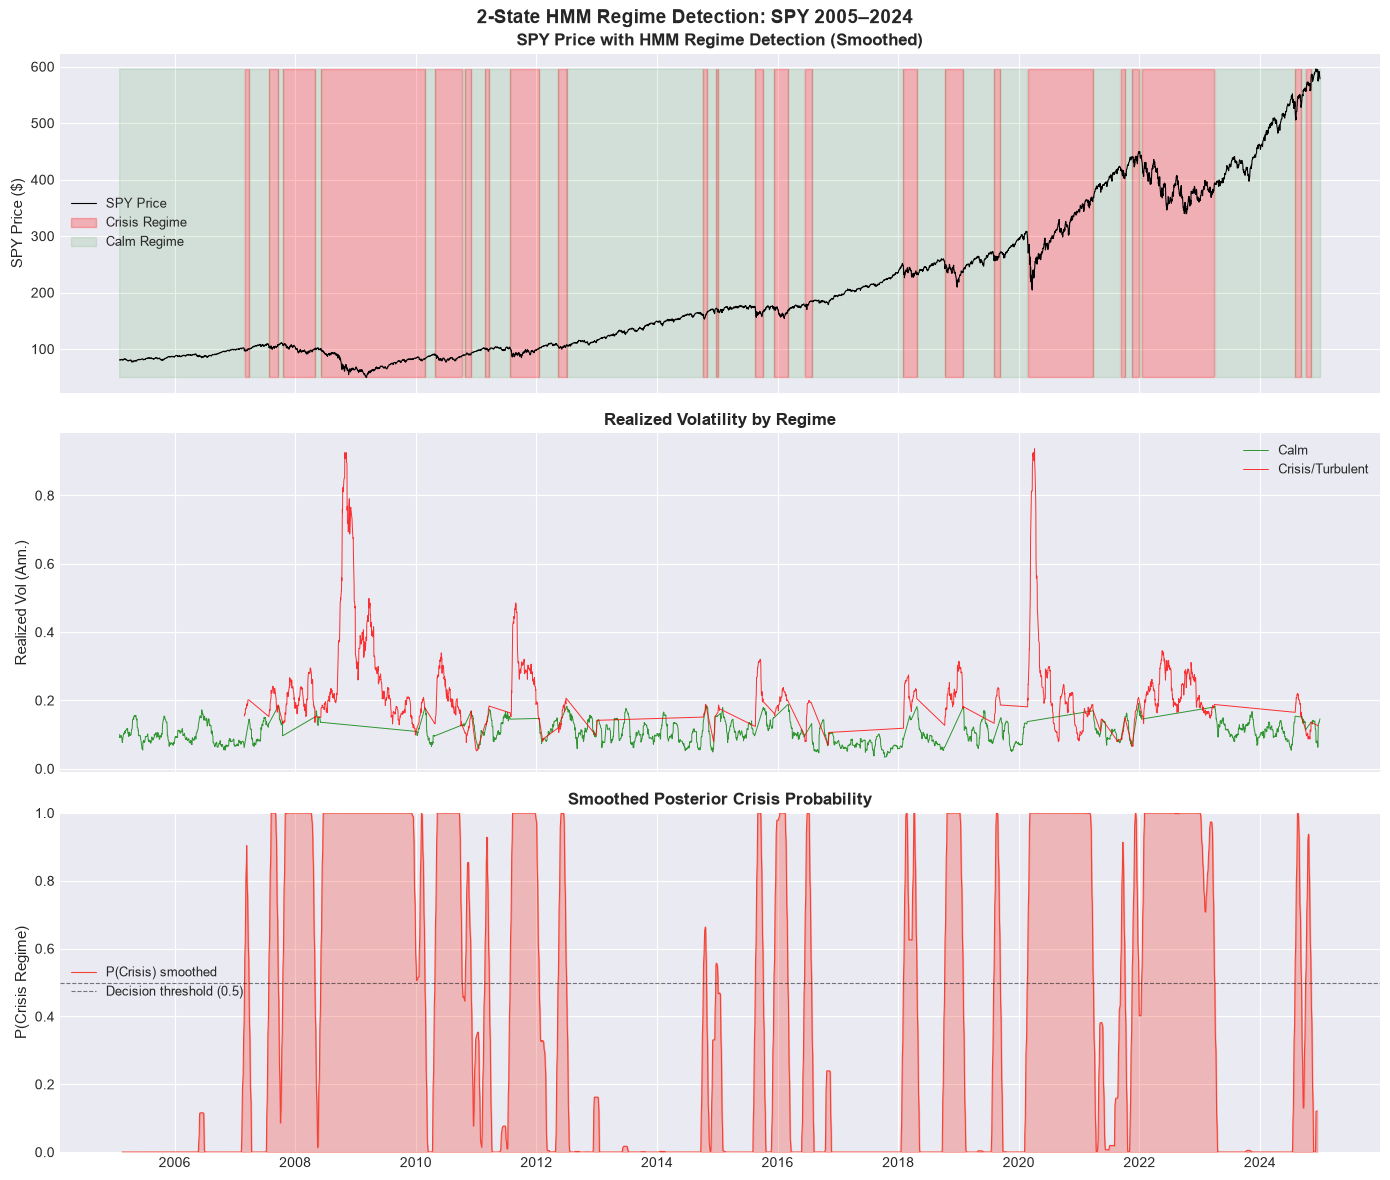


=== Regime Statistics ===

CALM REGIME (3065 days, 61.2%):
  Mean daily return:  0.0737%
  Return volatility:  0.6411%
  Mean realized vol:  0.1046
  Mean VIX:           14.37

CRISIS REGIME (1946 days, 38.8%):
  Mean daily return:  -0.0145%
  Return volatility:  1.7525%
  Mean realized vol:  0.2390
  Mean VIX:           26.76



In [8]:
# Add states to dataframe
data["state_2"] = states_2

# Identify which state is calm vs crisis based on realized vol mean
state_means = data.groupby("state_2")["realized_vol"].mean()
calm_state = state_means.idxmin()
crisis_state = state_means.idxmax()

print(f"Calm state:   State {calm_state} ({(states_2 == calm_state).sum()} days)")
print(f"Crisis state: State {crisis_state} ({(states_2 == crisis_state).sum()} days)")

# Use posterior probabilities smoothed with a rolling window for cleaner visualization
state_probs = hmm_2state.predict_proba(features_scaled)
crisis_prob_smooth = pd.Series(
    state_probs[:, crisis_state], 
    index=data.index
).rolling(window=21, center=True).mean()  # 21 days ~ 1 trading month

# Classify as crisis when smoothed probability > 0.5
regime_smooth = (crisis_prob_smooth > 0.5).astype(int)

spy_price = spy["Close"].reindex(data.index)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1 - SPY Price with smoothed regime shading
axes[0].plot(data.index, spy_price, color="black", linewidth=0.8, label="SPY Price")
axes[0].fill_between(data.index, spy_price.min(), spy_price.max(),
                      where=(regime_smooth == 1),
                      alpha=0.25, color="red", label="Crisis Regime")
axes[0].fill_between(data.index, spy_price.min(), spy_price.max(),
                      where=(regime_smooth == 0),
                      alpha=0.1, color="green", label="Calm Regime")
axes[0].set_ylabel("SPY Price ($)", fontsize=11)
axes[0].set_title("SPY Price with HMM Regime Detection (Smoothed)",
                   fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)

# Panel 2 - Realized volatility colored by regime
calm_mask = data["state_2"] == calm_state
crisis_mask = data["state_2"] == crisis_state

axes[1].plot(data.index[calm_mask], data["realized_vol"][calm_mask],
             color="green", linewidth=0.7, alpha=0.8, label="Calm")
axes[1].plot(data.index[crisis_mask], data["realized_vol"][crisis_mask],
             color="red", linewidth=0.7, alpha=0.8, label="Crisis/Turbulent")
axes[1].set_ylabel("Realized Vol (Ann.)", fontsize=11)
axes[1].set_title("Realized Volatility by Regime", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9)

# Panel 3 - Smoothed posterior probability
axes[2].plot(data.index, crisis_prob_smooth,
             color="#F44336", linewidth=0.8, label="P(Crisis) smoothed")
axes[2].axhline(y=0.5, color="black", linewidth=0.8,
                linestyle="--", alpha=0.5, label="Decision threshold (0.5)")
axes[2].fill_between(data.index, 0, crisis_prob_smooth,
                      alpha=0.3, color="#F44336")
axes[2].set_ylabel("P(Crisis Regime)", fontsize=11)
axes[2].set_title("Smoothed Posterior Crisis Probability",
                   fontsize=12, fontweight="bold")
axes[2].legend(fontsize=9)
axes[2].set_ylim(0, 1)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[2].xaxis.set_major_locator(mdates.YearLocator(2))

plt.suptitle("2-State HMM Regime Detection: SPY 2005–2024",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/03_hmm_2state_regimes.png", dpi=150, bbox_inches="tight")
plt.show()

# Print regime statistics using original unsmoothed states
print("\n=== Regime Statistics ===\n")
for state, label in [(calm_state, "CALM"), (crisis_state, "CRISIS")]:
    mask = data["state_2"] == state
    print(f"{label} REGIME ({mask.sum()} days, {mask.sum()/len(data)*100:.1f}%):")
    print(f"  Mean daily return:  {data.loc[mask, 'log_returns'].mean()*100:.4f}%")
    print(f"  Return volatility:  {data.loc[mask, 'log_returns'].std()*100:.4f}%")
    print(f"  Mean realized vol:  {data.loc[mask, 'realized_vol'].mean():.4f}")
    print(f"  Mean VIX:           {data.loc[mask, 'vix'].mean():.2f}")
    print()

Regimes assignments are extremely choppy, switching between calm and crisis almost daily in several periods.
The issue is .predict() uses smoothing across the entire sequence, which can produce cleaner or choppier results depending on the data. The choppiness suggests the model is uncertain about many days

Regime statistics are still valid:
- calm regime: mean return +.047%/day, realized vol 10.5%, VIX 14.27
- Crisis regime: mean return -.015%/day, realized vol 23.9%, VIX 26.76

2-state model shows excessive regime switching. The binary calm/crisis framework forces ambiguous periods into one of two states, producing choppy assignments in moderate volatility environments

Periods of high uncertainty
2011, 2014-2016, 2018, 2023-2024

A 3 state model (calm/turbulent/crisis) is better suited to capture the continuous spectrum of market volatility regimes. Moving to 3 state HMM

In [9]:
np.random.seed(42)

hmm_3state = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

hmm_3state.fit(features_scaled)
states_3 = hmm_3state.predict(features_scaled)

print("=== 3-State HMM Results ===\n")
print(f"Model converged: {hmm_3state.monitor_.converged}")
print(f"Iterations used: {hmm_3state.monitor_.iter}")
print(f"Log-likelihood:  {hmm_3state.score(features_scaled):.2f}")

print("\n=== Transition Matrix ===")
trans_df = pd.DataFrame(
    hmm_3state.transmat_,
    index=["State 0", "State 1", "State 2"],
    columns=["→ State 0", "→ State 1", "→ State 2"]
)
print(trans_df.round(4))

print("\n=== State Means (scaled) ===")
means_df = pd.DataFrame(
    hmm_3state.means_,
    index=["State 0", "State 1", "State 2"],
    columns=["log_returns", "realized_vol", "vix"]
)
print(means_df.round(4))

print("\n=== State Frequencies ===")
unique, counts = np.unique(states_3, return_counts=True)
for state, count in zip(unique, counts):
    print(f"State {state}: {count} days ({count/len(states_3)*100:.1f}%)")

=== 3-State HMM Results ===

Model converged: True
Iterations used: 110
Log-likelihood:  -8860.38

=== Transition Matrix ===
         → State 0  → State 1  → State 2
State 0     0.9819     0.0181     0.0000
State 1     0.0170     0.9733     0.0097
State 2     0.0000     0.0273     0.9727

=== State Means (scaled) ===
         log_returns  realized_vol     vix
State 0       0.0362       -0.5727 -0.7019
State 1      -0.0001       -0.0212  0.0548
State 2      -0.0988        1.6254  1.7637

=== State Frequencies ===
State 0: 2087 days (41.6%)
State 1: 2161 days (43.1%)
State 2: 763 days (15.2%)


State 0: Calm (41.6% of days)
- Positive returns, very low realized vol (-.57 scaled), very low VIX (-.70 scaled)
- bull market regime, low fear, steady gains

State 1: turbulent (43.1% of days)
- near zero returns, average vol and VIX (both near 0 scaled)
- intermediate state that was causing choppiness in the 2 state model. It's absorbing the ambiguous periods

State 2: crisis (15.2% of days)
- Negative returns (-.099 scaled), extremely high realized vol (+1.63 scaled), extremely high VIX (+1.76 scaled)

Transition matrix:
State 0 to state 2 probability: 0.0000, the model never jumps directly from calm to crisis
State 2 to state 0 probability: 0.0000, the model never jumps directly from crisis to calm
All transitions go through the turbulent middle state

Finding: markets don't flip instantly between calm and crisis, they transition through an intermediate turbulent state first. 

Log likelihood improved dramatically -8,860 vs -11,297 for the 2 state model

## 3 state model visualization

using a minimum duration filter, any regime shorter than 21 days is absorbed into the surrounding regime

Calm state:      State 0 (2087 days)
Turbulent state: State 1 (2161 days)
Crisis state:    State 2 (763 days)


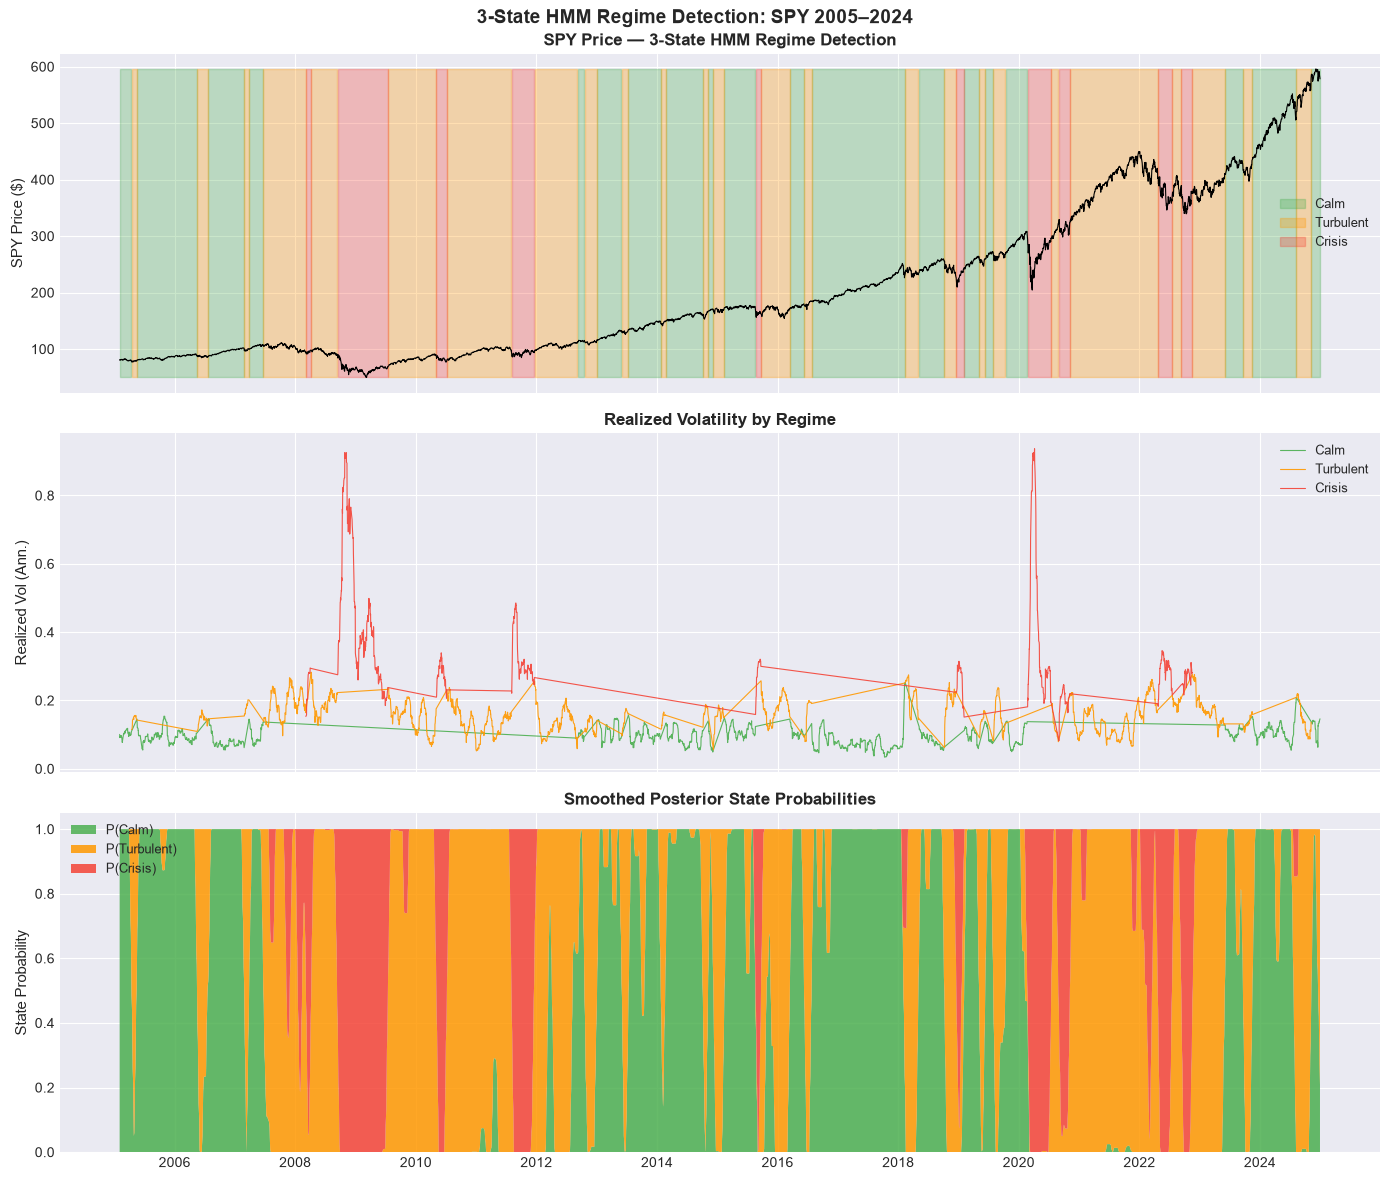


=== 3-State Regime Statistics ===

CALM REGIME (2087 days, 41.6%):
  Mean daily return:  0.0828%
  Return volatility:  0.5450%
  Mean realized vol:  0.0932
  Mean VIX:           13.01

TURBULENT REGIME (2161 days, 43.1%):
  Mean daily return:  0.0411%
  Return volatility:  0.9931%
  Mean realized vol:  0.1546
  Mean VIX:           19.65

CRISIS REGIME (763 days, 15.2%):
  Mean daily return:  -0.0840%
  Return volatility:  2.4238%
  Mean realized vol:  0.3368
  Mean VIX:           34.73



In [16]:
data["state_3"] = states_3

state_vol_means = data.groupby("state_3")["realized_vol"].mean()
calm_state = state_vol_means.idxmin()
crisis_state = state_vol_means.idxmax()
turbulent_state = [s for s in [0,1,2] 
                   if s != calm_state and s != crisis_state][0]

print(f"Calm state:      State {calm_state} ({(states_3==calm_state).sum()} days)")
print(f"Turbulent state: State {turbulent_state} ({(states_3==turbulent_state).sum()} days)")
print(f"Crisis state:    State {crisis_state} ({(states_3==crisis_state).sum()} days)")

# Apply minimum duration filter to clean up single-day flips
def apply_min_duration(states, min_days=5):
    cleaned = states.copy()
    i = 0
    while i < len(cleaned):
        current = cleaned[i]
        j = i
        while j < len(cleaned) and cleaned[j] == current:
            j += 1
        duration = j - i
        if duration < min_days and i > 0:
            cleaned[i:j] = cleaned[i-1]
        i = j
    return cleaned

# Map state numbers to labels
state_label_map = {
    calm_state: "calm",
    turbulent_state: "turbulent",
    crisis_state: "crisis"
}
states_labeled = np.array([state_label_map[s] for s in states_3])
states_cleaned = apply_min_duration(states_labeled, min_days=21)

color_map = {"calm": "#4CAF50", "turbulent": "#FF9800", "crisis": "#F44336"}
state_probs_3 = hmm_3state.predict_proba(features_scaled)

spy_price = spy["Close"].reindex(data.index)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1 - SPY Price with cleaned regime shading
axes[0].plot(data.index, spy_price, color="black", linewidth=0.8, zorder=3)
for regime, color in color_map.items():
    mask = states_cleaned == regime
    axes[0].fill_between(data.index,
                          float(spy_price.min()), float(spy_price.max()),
                          where=mask,
                          alpha=0.3, color=color,
                          label=regime.capitalize())
axes[0].set_ylabel("SPY Price ($)", fontsize=11)
axes[0].set_title("SPY Price — 3-State HMM Regime Detection",
                   fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)

# Panel 2 - Realized vol colored by cleaned regime
for regime, color in color_map.items():
    mask = states_cleaned == regime
    axes[1].plot(data.index[mask], data["realized_vol"][mask],
                 color=color, linewidth=0.8, alpha=0.9,
                 label=regime.capitalize())
axes[1].set_ylabel("Realized Vol (Ann.)", fontsize=11)
axes[1].set_title("Realized Volatility by Regime",
                   fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9)

# Panel 3 - Smoothed posterior probabilities
prob_calm = pd.Series(state_probs_3[:, calm_state],
                       index=data.index).rolling(21, center=True, min_periods=1).mean()
prob_turbulent = pd.Series(state_probs_3[:, turbulent_state],
                            index=data.index).rolling(21, center=True, min_periods=1).mean()
prob_crisis = pd.Series(state_probs_3[:, crisis_state],
                         index=data.index).rolling(21, center=True, min_periods=1).mean()

prob_sum = prob_calm + prob_turbulent + prob_crisis
prob_calm /= prob_sum
prob_turbulent /= prob_sum
prob_crisis /= prob_sum

axes[2].stackplot(data.index,
                  prob_calm, prob_turbulent, prob_crisis,
                  labels=["P(Calm)", "P(Turbulent)", "P(Crisis)"],
                  colors=["#4CAF50", "#FF9800", "#F44336"],
                  alpha=0.85)
axes[2].set_ylabel("State Probability", fontsize=11)
axes[2].set_title("Smoothed Posterior State Probabilities",
                   fontsize=12, fontweight="bold")
axes[2].legend(fontsize=9, loc="upper left")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[2].xaxis.set_major_locator(mdates.YearLocator(2))

plt.suptitle("3-State HMM Regime Detection: SPY 2005–2024",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/04_hmm_3state_regimes.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== 3-State Regime Statistics ===\n")
for state, label in [(calm_state, "CALM"),
                      (turbulent_state, "TURBULENT"),
                      (crisis_state, "CRISIS")]:
    mask = data["state_3"] == state
    print(f"{label} REGIME ({mask.sum()} days, {mask.sum()/len(data)*100:.1f}%):")
    print(f"  Mean daily return:  {data.loc[mask,'log_returns'].mean()*100:.4f}%")
    print(f"  Return volatility:  {data.loc[mask,'log_returns'].std()*100:.4f}%")
    print(f"  Mean realized vol:  {data.loc[mask,'realized_vol'].mean():.4f}")
    print(f"  Mean VIX:           {data.loc[mask,'vix'].mean():.2f}")
    print()

In [17]:
# Diagnose regime duration distribution
from itertools import groupby

durations = {"calm": [], "turbulent": [], "crisis": []}
for regime, group in groupby(states_labeled):
    durations[regime].append(sum(1 for _ in group))

print("=== Regime Duration Distribution ===\n")
for regime in ["calm", "turbulent", "crisis"]:
    d = durations[regime]
    print(f"{regime.upper()}:")
    print(f"  Number of distinct periods: {len(d)}")
    print(f"  Mean duration: {np.mean(d):.1f} days")
    print(f"  Median duration: {np.median(d):.1f} days")
    print(f"  Max duration: {np.max(d)} days")
    print(f"  Periods <= 5 days: {sum(1 for x in d if x <= 5)} ({sum(1 for x in d if x <= 5)/len(d)*100:.1f}%)")
    print(f"  Periods <= 21 days: {sum(1 for x in d if x <= 21)} ({sum(1 for x in d if x <= 21)/len(d)*100:.1f}%)")
    print()

=== Regime Duration Distribution ===

CALM:
  Number of distinct periods: 34
  Mean duration: 61.4 days
  Median duration: 34.5 days
  Max duration: 309 days
  Periods <= 5 days: 0 (0.0%)
  Periods <= 21 days: 9 (26.5%)

TURBULENT:
  Number of distinct periods: 54
  Mean duration: 40.0 days
  Median duration: 27.0 days
  Max duration: 207 days
  Periods <= 5 days: 6 (11.1%)
  Periods <= 21 days: 22 (40.7%)

CRISIS:
  Number of distinct periods: 20
  Mean duration: 38.1 days
  Median duration: 20.5 days
  Max duration: 210 days
  Periods <= 5 days: 2 (10.0%)
  Periods <= 21 days: 12 (60.0%)



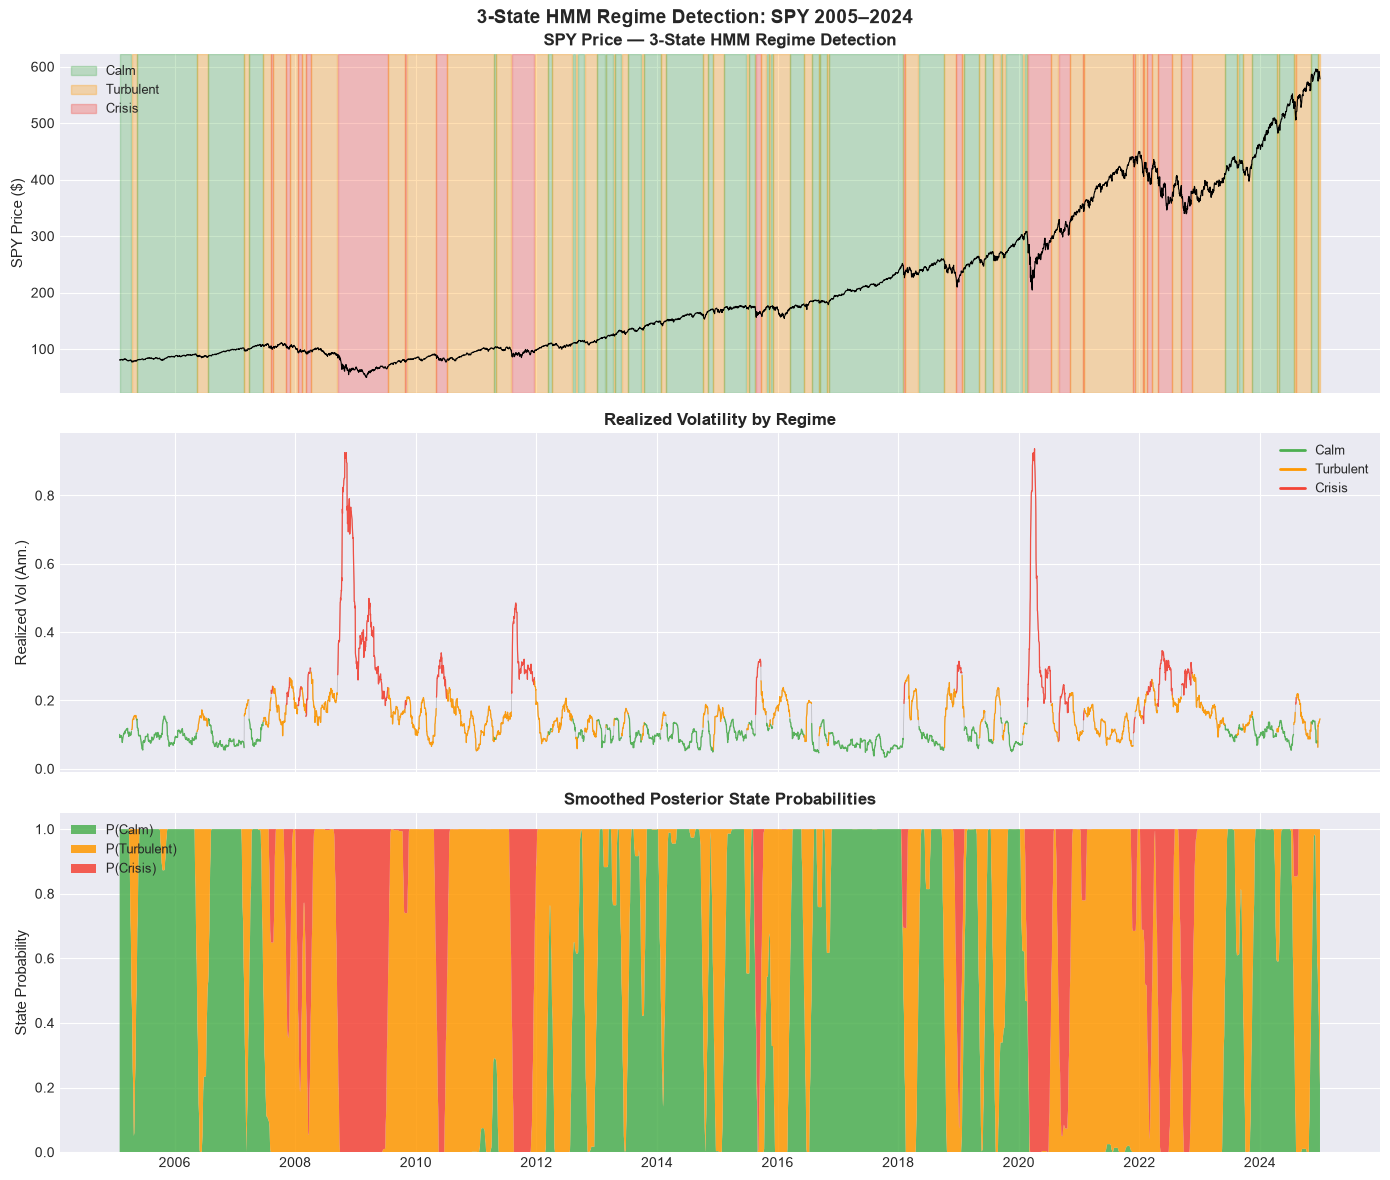


=== 3-State Regime Statistics ===

CALM REGIME (2087 days, 41.6%):
  Mean daily return:  0.0828%
  Return volatility:  0.5450%
  Mean realized vol:  0.0932
  Mean VIX:           13.01

TURBULENT REGIME (2161 days, 43.1%):
  Mean daily return:  0.0411%
  Return volatility:  0.9931%
  Mean realized vol:  0.1546
  Mean VIX:           19.65

CRISIS REGIME (763 days, 15.2%):
  Mean daily return:  -0.0840%
  Return volatility:  2.4238%
  Mean realized vol:  0.3368
  Mean VIX:           34.73



In [18]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

color_map = {"calm": "#4CAF50", "turbulent": "#FF9800", "crisis": "#F44336"}

# Build contiguous regime blocks
def get_regime_blocks(states, index):
    blocks = []
    current = states[0]
    start = index[0]
    for i in range(1, len(states)):
        if states[i] != current:
            blocks.append((current, start, index[i-1]))
            current = states[i]
            start = index[i]
    blocks.append((current, start, index[-1]))
    return blocks

blocks = get_regime_blocks(states_labeled, data.index)

spy_price = spy["Close"].reindex(data.index)
state_probs_3 = hmm_3state.predict_proba(features_scaled)

# Panel 1 - SPY Price with regime blocks
axes[0].plot(data.index, spy_price, color="black", linewidth=0.8, zorder=3)
legend_added = set()
for regime, start, end in blocks:
    label = regime.capitalize() if regime not in legend_added else None
    axes[0].axvspan(start, end, 
                    alpha=0.3, color=color_map[regime],
                    label=label)
    legend_added.add(regime)
axes[0].set_ylabel("SPY Price ($)", fontsize=11)
axes[0].set_title("SPY Price — 3-State HMM Regime Detection",
                   fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)

# Panel 2 - Realized vol with regime blocks
axes[1].plot(data.index, data["realized_vol"], 
             color="gray", linewidth=0.6, alpha=0.4, zorder=2)
for regime, start, end in blocks:
    mask = (data.index >= start) & (data.index <= end)
    axes[1].plot(data.index[mask], data["realized_vol"][mask],
                 color=color_map[regime], linewidth=0.9,
                 alpha=0.9, zorder=3)

# Manual legend for panel 2
from matplotlib.lines import Line2D
legend_lines = [Line2D([0], [0], color=color_map[r], linewidth=2, 
                        label=r.capitalize())
                for r in ["calm", "turbulent", "crisis"]]
axes[1].legend(handles=legend_lines, fontsize=9)
axes[1].set_ylabel("Realized Vol (Ann.)", fontsize=11)
axes[1].set_title("Realized Volatility by Regime",
                   fontsize=12, fontweight="bold")

# Panel 3 - Smoothed posterior probabilities
prob_calm = pd.Series(state_probs_3[:, calm_state],
                       index=data.index).rolling(21, center=True, min_periods=1).mean()
prob_turbulent = pd.Series(state_probs_3[:, turbulent_state],
                            index=data.index).rolling(21, center=True, min_periods=1).mean()
prob_crisis = pd.Series(state_probs_3[:, crisis_state],
                         index=data.index).rolling(21, center=True, min_periods=1).mean()

prob_sum = prob_calm + prob_turbulent + prob_crisis
prob_calm /= prob_sum
prob_turbulent /= prob_sum
prob_crisis /= prob_sum

axes[2].stackplot(data.index,
                  prob_calm, prob_turbulent, prob_crisis,
                  labels=["P(Calm)", "P(Turbulent)", "P(Crisis)"],
                  colors=["#4CAF50", "#FF9800", "#F44336"],
                  alpha=0.85)
axes[2].set_ylabel("State Probability", fontsize=11)
axes[2].set_title("Smoothed Posterior State Probabilities",
                   fontsize=12, fontweight="bold")
axes[2].legend(fontsize=9, loc="upper left")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[2].xaxis.set_major_locator(mdates.YearLocator(2))

plt.suptitle("3-State HMM Regime Detection: SPY 2005–2024",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/04_hmm_3state_regimes.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== 3-State Regime Statistics ===\n")
for state, label in [(calm_state, "CALM"),
                      (turbulent_state, "TURBULENT"),
                      (crisis_state, "CRISIS")]:
    mask = data["state_3"] == state
    print(f"{label} REGIME ({mask.sum()} days, {mask.sum()/len(data)*100:.1f}%):")
    print(f"  Mean daily return:  {data.loc[mask,'log_returns'].mean()*100:.4f}%")
    print(f"  Return volatility:  {data.loc[mask,'log_returns'].std()*100:.4f}%")
    print(f"  Mean realized vol:  {data.loc[mask,'realized_vol'].mean():.4f}")
    print(f"  Mean VIX:           {data.loc[mask,'vix'].mean():.2f}")
    print()

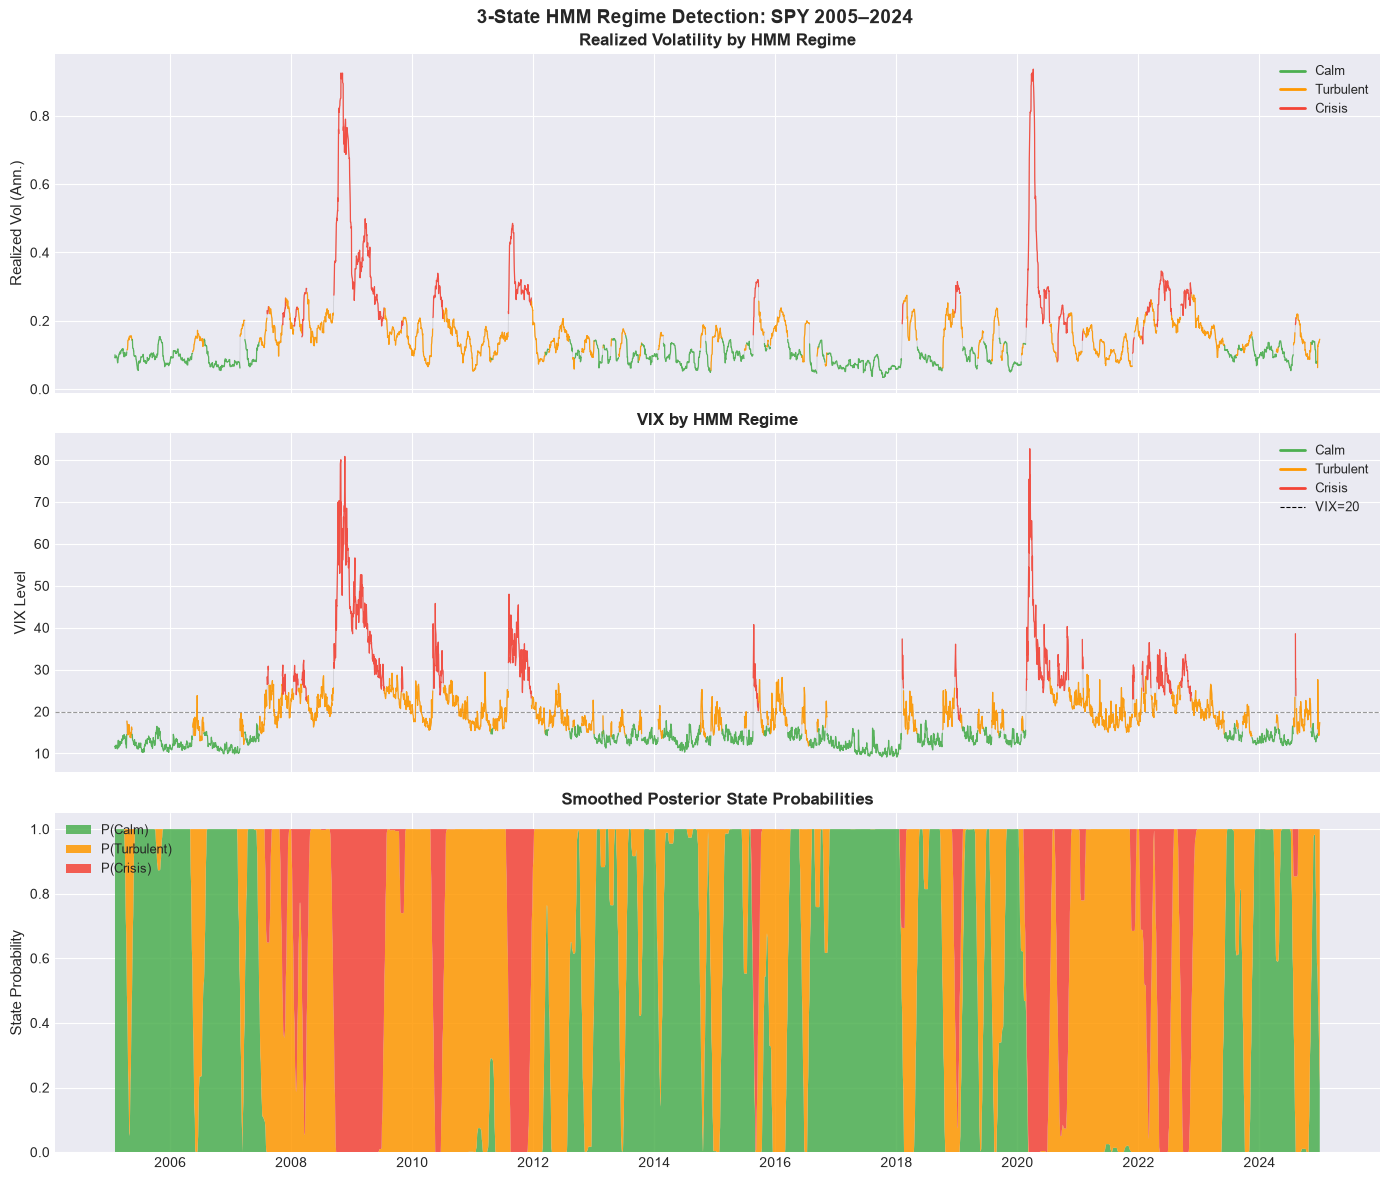

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

color_map = {"calm": "#4CAF50", "turbulent": "#FF9800", "crisis": "#F44336"}
blocks = get_regime_blocks(states_labeled, data.index)
state_probs_3 = hmm_3state.predict_proba(features_scaled)

# Panel 1 - Realized vol colored by regime (hero visual)
axes[0].plot(data.index, data["realized_vol"],
             color="gray", linewidth=0.5, alpha=0.3, zorder=2)
for regime, start, end in blocks:
    mask = (data.index >= start) & (data.index <= end)
    axes[0].plot(data.index[mask], data["realized_vol"][mask],
                 color=color_map[regime], linewidth=0.9, alpha=0.9, zorder=3)
from matplotlib.lines import Line2D
legend_lines = [Line2D([0], [0], color=color_map[r], linewidth=2,
                        label=f"{r.capitalize()}")
                for r in ["calm", "turbulent", "crisis"]]
axes[0].legend(handles=legend_lines, fontsize=9)
axes[0].set_ylabel("Realized Vol (Ann.)", fontsize=11)
axes[0].set_title("Realized Volatility by HMM Regime",
                   fontsize=12, fontweight="bold")

# Panel 2 - VIX colored by regime
axes[1].plot(data.index, data["vix"],
             color="gray", linewidth=0.5, alpha=0.3, zorder=2)
for regime, start, end in blocks:
    mask = (data.index >= start) & (data.index <= end)
    axes[1].plot(data.index[mask], data["vix"][mask],
                 color=color_map[regime], linewidth=0.9, alpha=0.9, zorder=3)
axes[1].axhline(y=20, color="black", linewidth=0.8,
                linestyle="--", alpha=0.4, label="VIX=20 threshold")
axes[1].legend(handles=legend_lines + [
    Line2D([0], [0], color="black", linewidth=0.8,
           linestyle="--", label="VIX=20")], fontsize=9)
axes[1].set_ylabel("VIX Level", fontsize=11)
axes[1].set_title("VIX by HMM Regime",
                   fontsize=12, fontweight="bold")

# Panel 3 - Smoothed posterior probabilities
prob_calm = pd.Series(state_probs_3[:, calm_state],
                       index=data.index).rolling(21, center=True, min_periods=1).mean()
prob_turbulent = pd.Series(state_probs_3[:, turbulent_state],
                            index=data.index).rolling(21, center=True, min_periods=1).mean()
prob_crisis = pd.Series(state_probs_3[:, crisis_state],
                         index=data.index).rolling(21, center=True, min_periods=1).mean()

prob_sum = prob_calm + prob_turbulent + prob_crisis
prob_calm /= prob_sum
prob_turbulent /= prob_sum
prob_crisis /= prob_sum

axes[2].stackplot(data.index,
                  prob_calm, prob_turbulent, prob_crisis,
                  labels=["P(Calm)", "P(Turbulent)", "P(Crisis)"],
                  colors=["#4CAF50", "#FF9800", "#F44336"],
                  alpha=0.85)
axes[2].set_ylabel("State Probability", fontsize=11)
axes[2].set_title("Smoothed Posterior State Probabilities",
                   fontsize=12, fontweight="bold")
axes[2].legend(fontsize=9, loc="upper left")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[2].xaxis.set_major_locator(mdates.YearLocator(2))

plt.suptitle("3-State HMM Regime Detection: SPY 2005–2024",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/04_hmm_3state_regimes.png", dpi=150, bbox_inches='tight')
plt.show()

- Panel 1: realized vol: green stays flat below .15 the entire time. Orange captures the elevated but no crisis periods, red spikes cleanly at GFC 2008, the 2011 European debt crisis, and Covid 2020. The three color separation is visually immediate and compelling
- Panel 2: VIX: green hugs below the VIX = 20 threshold almost perfectly. Orange oscillates around 20. Red breaks decisively above it during genuine crises. The VIX=20 dashed line works really well as a natural reference point
- Panel 3: Posterior probabilities. A bit choppy, shows model uncertainty during the tranisition periods. The posterior uncertainty between calm and turbulent regimes reflects the continuous nature of volatility, which motivates the line colored visualization in panels 1 and 2 as the primary output